In [ ]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("dschettler8845/brats-2021-task1")

# print("Path to dataset files:", path)


In [ ]:
# !mv /root/.cache/kagglehub/datasets/dschettler8845/brats-2021-task1/versions/1/ .
# !tar -xvf 1/BraTS2021_Training_Data.tar -C 1/
# !mv 1/*tar .
# !rm 1/.DS_Store

In [1]:
import os
from torch import nn
from torch.utils.data import Dataset, DataLoader
import torch
from torchvision.transforms import Compose, ToTensor
from torchvision import transforms, utils
import torch.nn.functional as F
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch.optim as optim
from torchvision.models import vgg16, VGG16_Weights

In [2]:
PATH = "1" 
patients = os.listdir(PATH)

train_patients = patients[0:len(patients) // 10 * 7]
val_patients = patients[len(patients) // 10 * 7:len(patients) // 10 * 9]
test_patients = patients[len(patients) // 10 * 9:]

print(len(train_patients), len(val_patients), len(test_patients))
print(len(patients)) # 1251 foldere a cate 4 slice-uri 3d + 1 seg
# for folder in os.listdir(PATH):
#     elems = os.listdir(os.path.join(PATH, folder))

875 250 126
1251


In [ ]:
class BraTSDataset(Dataset):
    def __init__(self, patients_list : list[str], transforms = None):
        self.groundtruth = []
        self.transforms = transforms
        self.patients_list = patients_list
        self.t1ce = []
        self.t1 = []
        self.t2 = []
        self.flair = []
        for patient in patients_list:
            patient_folder = os.path.join(PATH, patient) # pune path corect pana la fiecare folder cu cate 5 poze si elems e un vect de 5 poze
            for photo_name in os.listdir(patient_folder):
                if "seg.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name) # path-ul fiecarei poze din fiecare folder al pacientului e pus in vect
                    self.groundtruth.append(path_photo)
                elif "t1ce.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name) # path-ul fiecarei poze din fiecare folder al pacientului e pus in vect
                    self.t1ce.append(path_photo)
                elif "t1.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name) 
                    self.t1.append(path_photo)
                elif "t2.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name)
                    self.t2.append(path_photo)
                elif "flair.nii.gz" in photo_name:
                    path_photo = os.path.join(patient_folder, photo_name)
                    self.flair.append(path_photo)
        # print(self.t1ce)
        # print()
        # print(self.t1)
        # print()
        # print(self.t2)
        # print()
        # print(self.flair)
        # print()
        # print(self.groundtruth)


    def __len__(self): # fctie pt nr de pacienti din dataset
        return len(self.patients_list)

    def __getitem__(self, idx: int):
        # Load all MRI modalities
        nii_t1    = nib.load(self.t1[idx])
        nii_t1ce  = nib.load(self.t1ce[idx])
        nii_t2    = nib.load(self.t2[idx])
        nii_flair = nib.load(self.flair[idx])
        nii_seg   = nib.load(self.groundtruth[idx])

    # Get numpy arrays
        t1_data    = nii_t1.get_fdata().astype(np.float32)
        t1ce_data  = nii_t1ce.get_fdata().astype(np.float32)
        t2_data    = nii_t2.get_fdata().astype(np.float32)
        flair_data = nii_flair.get_fdata().astype(np.float32)
        seg_data   = nii_seg.get_fdata().astype(np.float32)  # segmentation mask

        # deci am 155 de imag t1, 155 t2.., si fac crop la poza la 128 din 240 (un patch)
        h = np.random.randint(0, t1_data.shape[1] - 128)
        w = np.random.randint(0, t1_data.shape[2] - 128)
        t1_data = t1_data[h:h+128, w:w+128, :]
        t1ce_data = t1ce_data[h:h+128, w:w+128, :]
        t2_data = t2_data[h:h+128, w:w+128, :]
        flair_data = flair_data[h:h+128, w:w+128, :]
        seg_data = seg_data[h:h+128, w:w+128, :]

    # normalize each modality (z-score over non-zero voxels)
        def normalize(x):
            mask = x > 0
            if np.any(mask):
                x[mask] = (x[mask] - x[mask].mean()) / (x[mask].std() + 1e-8)
                x[~mask] = 0
            return x

        t1_data    = normalize(t1_data)
        t1ce_data  = normalize(t1ce_data)
        t2_data    = normalize(t2_data)
        flair_data = normalize(flair_data)

        # Stack MRI modalities along channel dimension -> (4, H, W, D)
        image_data = np.stack([t1_data, t1ce_data, t2_data, flair_data], axis=0)
        image_data = torch.from_numpy(image_data).float()

        # Segmentation mask -> (1, H, W, D)
        seg_data_mapped = np.zeros_like(seg_data, dtype=np.int64)
        seg_data_mapped[seg_data == 4] = 3 # schimb label ul din 4 in 3
        groundtruth_data = torch.from_numpy(seg_data_mapped).long()
        return image_data[:, :, :, 3:147], groundtruth_data[:, :, 3:147] # de la 147 la 155 erau negre asa ca le-am scos

    
    def display_axial_slice_all(self, idx: int, slice_index=None):
    # Load MRI modalities
        nii_t1    = nib.load(self.t1[idx])
        nii_t1ce  = nib.load(self.t1ce[idx])
        nii_t2    = nib.load(self.t2[idx])
        nii_flair = nib.load(self.flair[idx])
        nii_seg   = nib.load(self.groundtruth[idx])

    # Get data
        t1_data    = nii_t1.get_fdata()
        t1ce_data  = nii_t1ce.get_fdata()
        t2_data    = nii_t2.get_fdata()
        flair_data = nii_flair.get_fdata()
        seg_data   = nii_seg.get_fdata()

    # Choose slice index along z-axis
        if slice_index is None:
            slice_index = t1_data.shape[2] // 2  # daca nu spun ce slice sa-mi arate, il ia default pe ala din mijloc

    # Extract slices
        t1_slice    = t1_data[:, :, slice_index]
        t1ce_slice  = t1ce_data[:, :, slice_index]
        t2_slice    = t2_data[:, :, slice_index]
        flair_slice = flair_data[:, :, slice_index]
        seg_slice   = seg_data[:, :, slice_index]

    # Plot 5 images side by side
        fig, axes = plt.subplots(1, 5, figsize=(20, 5))

    # MRI slices
        axes[0].imshow(np.rot90(t1_slice), cmap="gray")
        axes[0].set_title("T1")
        axes[0].axis("off")

        axes[1].imshow(np.rot90(t1ce_slice), cmap="gray")
        axes[1].set_title("T1ce")
        axes[1].axis("off")

        axes[2].imshow(np.rot90(t2_slice), cmap="gray")
        axes[2].set_title("T2")
        axes[2].axis("off")

        axes[3].imshow(np.rot90(flair_slice), cmap="gray")
        axes[3].set_title("FLAIR")
        axes[3].axis("off")

    # Segmentation (discrete values mapped to colors)
        cmap = plt.cm.get_cmap("tab10", 4)
        im = axes[4].imshow(np.rot90(seg_slice), cmap=cmap, vmin=0, vmax=4)
        axes[4].set_title("Segmentation")
        axes[4].axis("off")

    # Add colorbar for segmentation
        cbar = fig.colorbar(im, ax=axes[4], fraction=0.046, pad=0.04)
        cbar.set_ticks([0, 1, 2, 4])
        cbar.set_label("Tumor class")

        plt.show()


In [ ]:
training_dataset = BraTSDataset(train_patients)
val_dataset = BraTSDataset(val_patients)
test_dataset = BraTSDataset(test_patients)
train_loader = DataLoader(
    training_dataset,
    batch_size=1,      # cati pacienti procesez in reteaua neurala o data
    shuffle=True,      # shuffle for training
    num_workers=4,     # adjust based on CPU cores, 4 threaduri care citesc datele din fisierele .nii
)

val_loader = DataLoader(
    val_dataset,
    batch_size=1,      # no shuffling for validation
    shuffle=False,
    num_workers=4,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,      # no shuffling for testing
    shuffle=False,
    num_workers=4,
)

torch.Size([4, 128, 128, 144]) torch.Size([128, 128, 144])


C:\Users\ingri\AppData\Local\Temp\ipykernel_24036\3557721507.py:136: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab10", 4)


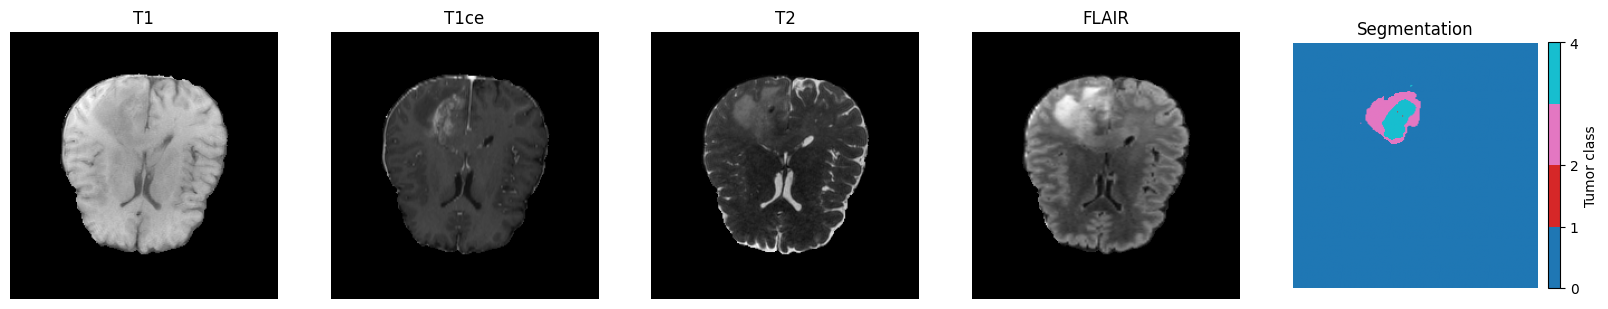

In [ ]:
idx : int = 21
img_data, segmentation_data = training_dataset.__getitem__(idx)
print(img_data.shape, segmentation_data.shape)
training_dataset.display_axial_slice_all(idx, 77) # pacientul idx din 1251, 70 e slice-ul din mri 3d 


In [ ]:
# vgg e pt imag 2d, l-am facut pt 3d
# convolutia e un strat
# Relu e fctie de activare
def inflate_conv2d_to_conv3d(conv2d, in_channels=None):
    kernel_2d = conv2d.weight.data
    kH, kW = kernel_2d.shape[2], kernel_2d.shape[3]
    kD = 3  # choose depth kernel size 3
    kernel_3d = kernel_2d.unsqueeze(2).repeat(1, 1, kD, 1, 1) / kD
    if in_channels is not None and in_channels != conv2d.in_channels:
        # average existing channels, repeat for extra channels
        kernel_3d = kernel_3d[:, :in_channels, :, :, :]
    conv3d = nn.Conv3d(
        in_channels=in_channels if in_channels is not None else conv2d.in_channels,
        out_channels=conv2d.out_channels,
        kernel_size=(kD, kH, kW),
        padding=(1, 1, 1),
        bias=(conv2d.bias is not None)
    )
    conv3d.weight.data.copy_(kernel_3d)
    if conv2d.bias is not None:
        conv3d.bias.data.copy_(conv2d.bias.data)
    return conv3d

class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.BatchNorm3d(out_ch),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class VGG3DUNet(nn.Module):
    def __init__(self, in_channels=4, out_channels=4):
        super().__init__()
        vgg = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features
        self.preconv = nn.Conv3d(in_channels=4, out_channels=3, kernel_size=3, padding=1)

        # Build encoder from VGG16 conv blocks
        self.enc1 = nn.Sequential(
            inflate_conv2d_to_conv3d(vgg[0], in_channels=3),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True),
            inflate_conv2d_to_conv3d(vgg[2], in_channels=64),
            nn.BatchNorm3d(64),
            nn.ReLU(inplace=True)
        )
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = nn.Sequential(
            inflate_conv2d_to_conv3d(vgg[5], in_channels=64),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True),
            inflate_conv2d_to_conv3d(vgg[7], in_channels=128),
            nn.BatchNorm3d(128),
            nn.ReLU(inplace=True)
        )
        self.pool2 = nn.MaxPool3d(2)

        self.enc3 = nn.Sequential(
            inflate_conv2d_to_conv3d(vgg[10], in_channels=128),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            inflate_conv2d_to_conv3d(vgg[12], in_channels=256),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True),
            inflate_conv2d_to_conv3d(vgg[14], in_channels=256),
            nn.BatchNorm3d(256),
            nn.ReLU(inplace=True)
        )
        self.pool3 = nn.MaxPool3d(2)

        self.enc4 = nn.Sequential(
            inflate_conv2d_to_conv3d(vgg[17], in_channels=256),
            nn.BatchNorm3d(512),
            nn.ReLU(inplace=True),
            inflate_conv2d_to_conv3d(vgg[19], in_channels=512),
            nn.BatchNorm3d(512),
            nn.ReLU(inplace=True),
            inflate_conv2d_to_conv3d(vgg[21], in_channels=512),
            nn.BatchNorm3d(512),
            nn.ReLU(inplace=True)
        )
        self.pool4 = nn.MaxPool3d(2)

        # Bottleneck
        self.bottleneck = DoubleConv3D(512, 1024)

        # Decoder
        self.up4 = nn.ConvTranspose3d(1024, 512, kernel_size=2, stride=2)
        self.dec4 = DoubleConv3D(1024, 512)

        self.up3 = nn.ConvTranspose3d(512, 256, kernel_size=2, stride=2)
        self.dec3 = DoubleConv3D(512, 256)

        self.up2 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(256, 128)

        self.up1 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(128, 64)

        # Output
        self.out_conv = nn.Conv3d(64, out_channels, kernel_size=1)

    def forward(self, x):
        # apelez straturile si zic cum va trece inputul prin ele
        # Encoder
        x = self.preconv(x)
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b  = self.bottleneck(self.pool4(e4))

        # Decoder
        d4 = self.up4(b)
        d4 = torch.cat([d4, e4], dim=1)
        d4 = self.dec4(d4)

        d3 = self.up3(d4)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)
        return out


In [ ]:
def dice_score(pred, target, num_classes=4, smooth=1e-5):
    dice_per_class = []
    for c in range(num_classes):
        pred_c = (pred == c).float()
        target_c = (target == c).float()

        intersection = (pred_c * target_c).sum()
        union = pred_c.sum() + target_c.sum()

        if target_c.sum() == 0 and pred_c.sum() == 0:
            dice = torch.tensor(1.0)
        else:
            dice = (2. * intersection + smooth) / (union + smooth)

        dice_per_class.append(dice.item())
    return dice_per_class

class DiceCEComboLoss(nn.Module):
    def __init__(self, weight_ce=1.0, weight_dice=1.0):
        super().__init__()
        self.ce = nn.CrossEntropyLoss()
        self.weight_ce = weight_ce
        self.weight_dice = weight_dice

    def forward(self, logits, target):
        """
        logits: (B-nr de elem din batch, C-nr canale, H, W, D-nr poze) #pred
        target: (B, H, W, D) #ce trebuia sa obtin
        """
        ce_loss = self.ce(logits, target)

        # Dice part
        probs = F.softmax(logits, dim=1)  # (B, C, H, W, D)
        target_onehot = F.one_hot(target, num_classes=logits.shape[1])  # (B, H, W, D, C)
        target_onehot = target_onehot.permute(0, 4, 1, 2, 3).float()   # (B, C, H, W, D)

        smooth = 1e-5
        intersection = (probs * target_onehot).sum(dim=(0,2,3,4))
        union = probs.sum(dim=(0,2,3,4)) + target_onehot.sum(dim=(0,2,3,4))
        dice_loss = 1 - (2 * intersection + smooth) / (union + smooth)
        dice_loss = dice_loss.mean()

        return self.weight_ce * ce_loss + self.weight_dice * dice_loss



In [9]:
def train_one_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0

    for idx, (X, y) in enumerate(dataloader):
        # X e imaginea, y e segmentare
        print(f"{idx} aici")
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(X)  # (B, C, H, W, D)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)

    return running_loss / len(dataloader.dataset) # loss mediu pt tot setul de train

def validate(model, dataloader, criterion, device):
    model.eval()
    val_loss = 0.0
    dice_scores = []

    with torch.no_grad():
        # tine de tensori, anulez gradientul ca sa ruleze mai repede cand fac validare/testare
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            loss = criterion(logits, y)
            val_loss += loss.item() * X.size(0)

            preds = torch.argmax(logits, dim=1)
            dice_per_sample = [dice_score(pred.unsqueeze(0), y.unsqueeze(0)) for pred in preds]
            dice_scores.extend(dice_per_sample)

    # Average Dice per class across dataset
    dice_scores = torch.tensor(dice_scores).float()
    mean_dice_per_class = dice_scores.mean(dim=0).tolist()

    return val_loss / len(dataloader.dataset), mean_dice_per_class # 4 dice-uri, pt fiecare clasa cate unul

def test(model, dataloader, device):
    model.eval()
    dice_scores = []

    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            logits = model(X)
            preds = torch.argmax(logits, dim=1)
            dice_per_sample = [dice_score(pred.unsqueeze(0), y.unsqueeze(0)) for pred in preds]
            dice_scores.extend(dice_per_sample)

    # Average Dice per class across dataset
    dice_scores = torch.tensor(dice_scores).float()
    mean_dice_per_class = dice_scores.mean(dim=0).tolist()
    return mean_dice_per_class



In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
model = VGG3DUNet(in_channels=4, out_channels=4).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = DiceCEComboLoss()
print("incepe antrenarea")
for epoch in range(1, 2):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_dice = validate(model, val_loader, criterion, device)
    print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Val Dice={val_dice}")
    # train loss = 0.66, val loss = 0.65, val_dice=[0.95, 1, 1, 0.44]
    # to do train_dice


In [ ]:
test_dice = test(model, test_loader, device)
print(f"Test Dice per class: {test_dice}")
